In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os
from sklearn.tree import plot_tree



CSVLOC = "./CLMerged1sec.csv"
JOBLIB_MODEL = 'rf_model_final.joblib'
JOBLIB_SCALER = 'scaler_final.joblib'
JOBLIB_FEATURES = 'features_list.joblib'
JOBLIB_LE = 'le_class.joblib'


# 1. Cargar el "cerebro" y las "gafas" (Modelo y Escalador)
folder = 'joblibs'
try:
    modelo = joblib.load(os.path.join(folder, JOBLIB_MODEL))
    scaler = joblib.load(os.path.join(folder, JOBLIB_SCALER))
    features = joblib.load(os.path.join(folder, JOBLIB_FEATURES))
    le = joblib.load(os.path.join(folder, JOBLIB_LE))
    print("Artefactos cargados correctamente desde el servidor.")
except FileNotFoundError:
    print("Error: Asegúrate de tener los archivos .joblib en la misma carpeta.")

# 2. Reconstrucción del set de Test
# Cargamos el CSV limpio para extraer la porción que el modelo NO ha visto
df = pd.read_csv(CSVLOC)
X = df.drop(columns=['target'])
y = df['target']

# Es CRÍTICO usar el mismo random_state que en el servidor para que el test sea real
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Transformación de los datos
# Nunca re-ajustes el scaler, solo usa .transform()
X_test_scaled = scaler.transform(X_test)
print(f"Examen listo: {X_test.shape[0]} muestras preparadas para evaluación.")

Artefactos cargados correctamente desde el servidor.
Examen listo: 45439 muestras preparadas para evaluación.


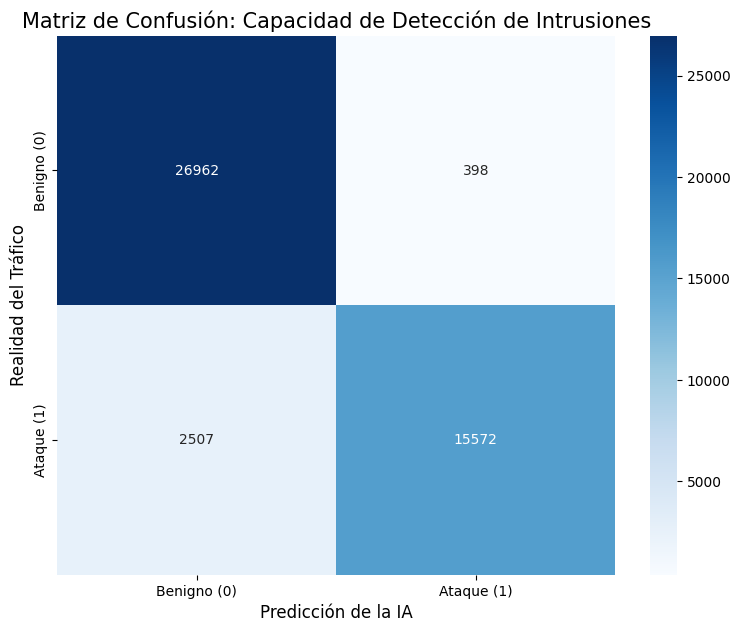


             REPORTE TÉCNICO DE CLASIFICACIÓN
              precision    recall  f1-score   support

     Benigno       0.91      0.99      0.95     27360
      Ataque       0.98      0.86      0.91     18079

    accuracy                           0.94     45439
   macro avg       0.95      0.92      0.93     45439
weighted avg       0.94      0.94      0.94     45439



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obtener las etiquetas únicas presentes en el test
# Esto nos permite saber si estamos en modo 2, 8 o 61 clases automáticamente
clases_detectadas = np.unique(y_test)
n_clases = len(clases_detectadas)

# 2. Configurar nombres de etiquetas
# Si usaste el LabelEncoder 'le' en el preprocesamiento, lo usamos aquí
if 'le' in locals():
    target_names = le.classes_
elif n_clases == 2:
    target_names = ['Benigno (0)', 'Ataque (1)']
else:
    target_names = [f'Clase {i}' for i in clases_detectadas]

# 3. Realizar predicciones
y_pred = modelo.predict(X_test_scaled)

# 4. Configuración visual dinámica de la matriz
cm = confusion_matrix(y_test, y_pred)

# Ajustamos el tamaño de la figura: si hay 61 clases, necesitamos un lienzo grande (15x12)
plt.figure(figsize=(10 if n_clases <= 8 else 18, 8 if n_clases <= 8 else 14))

# annot=True solo si hay pocas clases para que no se amontone el texto
sns.heatmap(cm, annot=(n_clases <= 10), fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)

plt.title(f'Matriz de Confusión: Detección ({n_clases} clases)', fontsize=15)
plt.xlabel('Predicción de la IA', fontsize=12)
plt.ylabel('Realidad del Tráfico', fontsize=12)
plt.xticks(rotation=45 if n_clases > 2 else 0) # Rotar etiquetas si hay muchas
plt.show()

# 5. Resumen estadístico adaptable
print("\n" + "="*60)
print(f"       REPORTE TÉCNICO DE CLASIFICACIÓN ({n_clases} CLASES)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=target_names))

/tmp/ipykernel_52774/553611944.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Métrica de Red', data=importancias.head(12), palette='viridis')


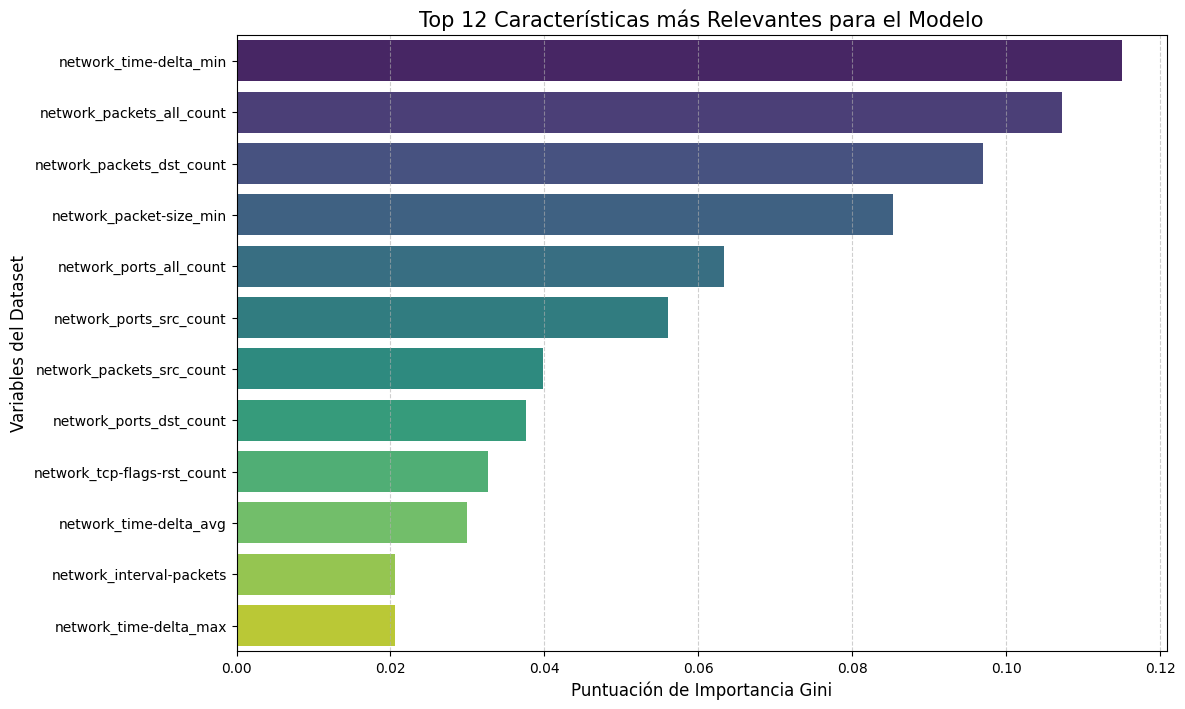


--- Tabla de importancia (Top 5) ---
               Métrica de Red  Importancia
61     network_time-delta_min     0.115065
36  network_packets_all_count     0.107189
37  network_packets_dst_count     0.096913
34    network_packet-size_min     0.085258
43    network_ports_all_count     0.063283


In [4]:
# Extracción de la sabiduría del Random Forest
importancias = pd.DataFrame({
    'Métrica de Red': features,
    'Importancia': modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización del Top 12 (las más críticas)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Métrica de Red', data=importancias.head(12), palette='viridis')

plt.title('Top 12 Características más Relevantes para el Modelo', fontsize=15)
plt.xlabel('Puntuación de Importancia Gini', fontsize=12)
plt.ylabel('Variables del Dataset', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Mostrar la tabla de datos para análisis escrito
print("\n--- Tabla de importancia (Top 5) ---")
print(importancias.head(5))

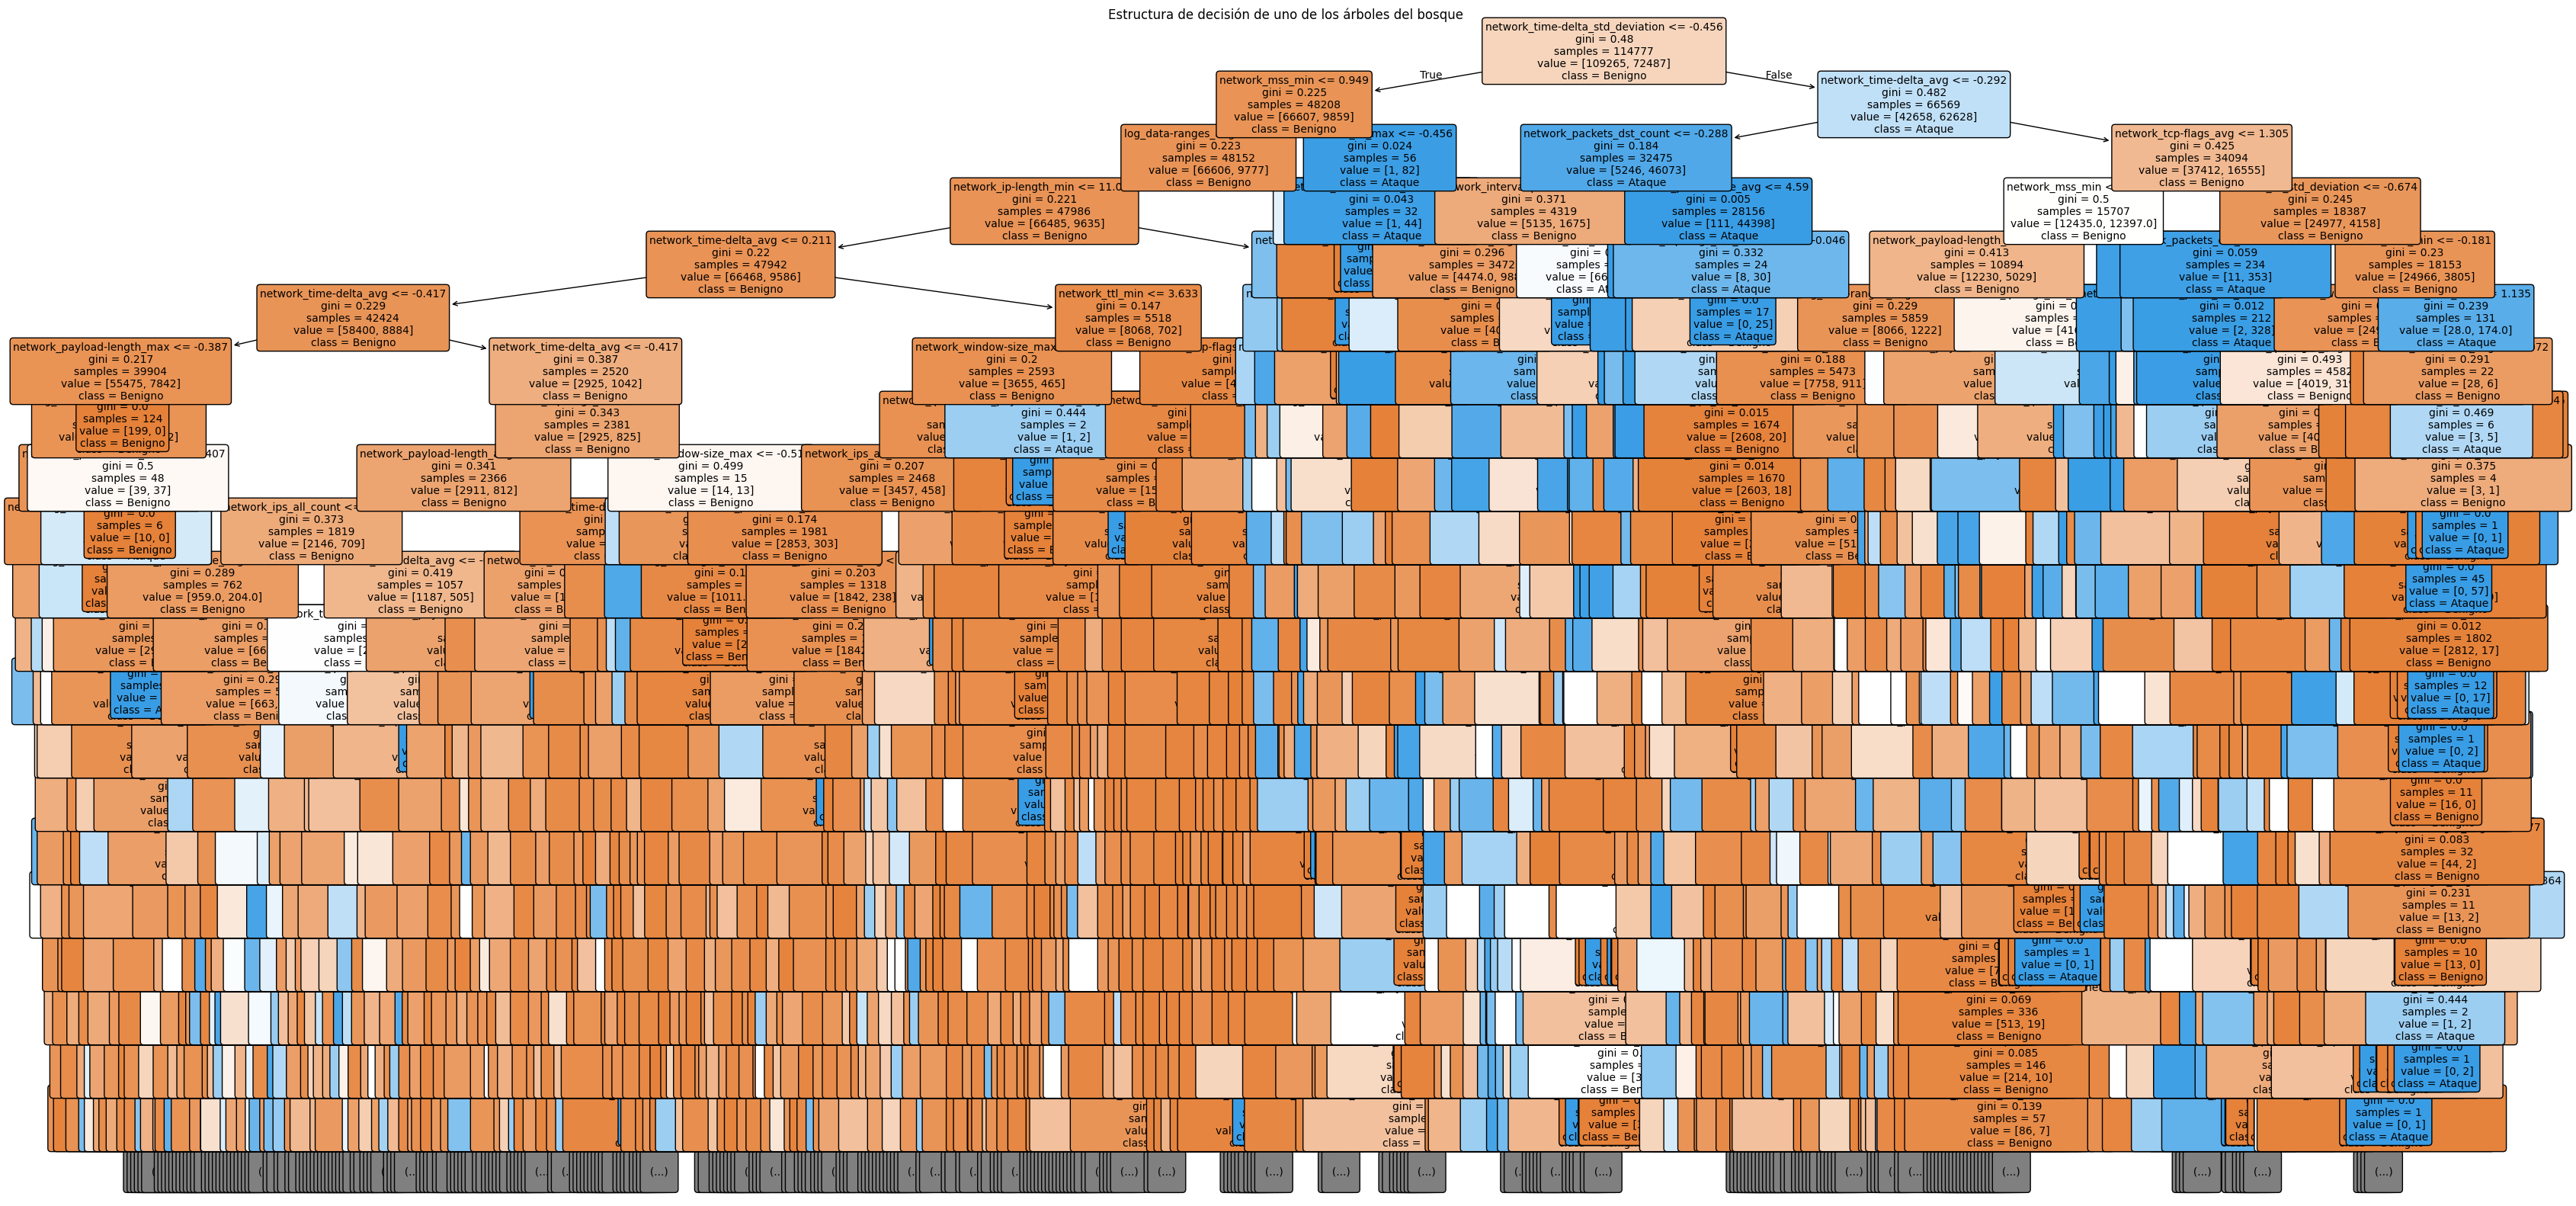

In [9]:
plt.figure(figsize=(40, 20))

# Dibujamos el primer árbol del bosque
# max_depth=3 para que sea legible; si no, será un caos de ramas
plot_tree(modelo.estimators_[0], 
          feature_names=features, 
          class_names=['Benigno', 'Ataque'], 
          filled=True, 
          rounded=True, 
          max_depth=20, 
          fontsize=10)

plt.title("Estructura de decisión de uno de los árboles del bosque")
plt.show()